# Decision Tree Model

### Step 1 : Import Libraries

In [102]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score

### Step 2: Make DataFrame

In [103]:
dataFrame = {
              "Weather":["Sunny","Sunny","Overcast","Rainy","Rainy","Rainy", "Overcast","Sunny","Sunny", "Rainy",  "Sunny",  "Overcast", "Overcast", "Rainy"],
              "Humidity":["High","High","High","High","Normal","Normal","Normal","High","Normal","Normal","Normal","High","Normal","High"],
              "Wind":["Weak","Strong","Weak","Weak","Weak","Strong","Strong","Weak","Weak","Weak","Strong","Strong","Weak","Strong"],
              "Play":["No","No","Yes","Yes","Yes","No","Yes","No","Yes","Yes","Yes","Yes","Yes","No"]
             }
df = pd.DataFrame(dataFrame)
df.head()


,Weather,Humidity,Wind,Play
0,Sunny,High,Weak,No
1,Sunny,High,Strong,No
2,Overcast,High,Weak,Yes
3,Rainy,High,Weak,Yes
4,Rainy,Normal,Weak,Yes


### Step 3: Data Preprocessing

In [104]:
# Checking Datatype of Features
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Weather   14 non-null     str  
 1   Humidity  14 non-null     str  
 2   Wind      14 non-null     str  
 3   Play      14 non-null     str  
dtypes: str(4)
memory usage: 580.0 bytes


#### Apply Label Encoding on 'Weather' Feature because Nominal Data (No connection between data)

In [105]:
# Checking the Categories
df["Weather"].unique()

<StringArray>
['Sunny', 'Overcast', 'Rainy']
Length: 3, dtype: str

In [106]:
# Converting String Features into Numerical Features for better results
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Weather"] = le.fit_transform(df["Weather"])  # Sunny = 2, Overcast = 0, Rainy = 1
df.head()

,Weather,Humidity,Wind,Play
0,2,High,Weak,No
1,2,High,Strong,No
2,0,High,Weak,Yes
3,1,High,Weak,Yes
4,1,Normal,Weak,Yes


#### Apply Ordinal Encoding on 'Humidity' & 'Wind' Features because of Order Data

In [107]:
# Converting String Features into Numerical Features for better results
h_order=[["Normal","High"]]
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder(categories=h_order)
df["Humidity"] = oe.fit_transform(df[["Humidity"]])
df.head()

,Weather,Humidity,Wind,Play
0,2,1.0,Weak,No
1,2,1.0,Strong,No
2,0,1.0,Weak,Yes
3,1,1.0,Weak,Yes
4,1,0.0,Weak,Yes


In [108]:
w_order=[["Weak","Strong"]]
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder(categories=w_order)
df["Wind"] = oe.fit_transform(df[["Wind"]])
df.head()

,Weather,Humidity,Wind,Play
0,2,1.0,0.0,No
1,2,1.0,1.0,No
2,0,1.0,0.0,Yes
3,1,1.0,0.0,Yes
4,1,0.0,0.0,Yes


#### Apply One Hot Encoding on 'Play' Feature because of Ordinal Data (Connection between data)

In [109]:
from sklearn.preprocessing import OneHotEncoder
oh = OneHotEncoder()
df["Play"] = oh.fit_transform(df[["Play"]]).toarray()
df.head()

,Weather,Humidity,Wind,Play
0,2,1.0,0.0,1.0
1,2,1.0,1.0,1.0
2,0,1.0,0.0,0.0
3,1,1.0,0.0,0.0
4,1,0.0,0.0,0.0


In [110]:
# Again Checking the datatypes of dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Weather   14 non-null     int64  
 1   Humidity  14 non-null     float64
 2   Wind      14 non-null     float64
 3   Play      14 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 580.0 bytes


#### All Features are converting to Numerical form.

### Step 4: Split Data into Training and Testing Sets

In [111]:
X = df[["Weather","Humidity","Wind"]]
y = df[["Play"]]

### Step 5: Applying Decision Tree Model & Train it

In [112]:
de = DecisionTreeClassifier(criterion="entropy",max_depth=3)
de.fit(X,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

### Step 6: Prediction

In [113]:
y_predict = de.predict(X)
print(y_predict)

[1. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


### Step 7: Checking Accuracy of Model

In [114]:
de_accuracy = accuracy_score(y,y_predict)
print(de_accuracy*100)

85.71428571428571


### Step 8: Displaying Decision Tree

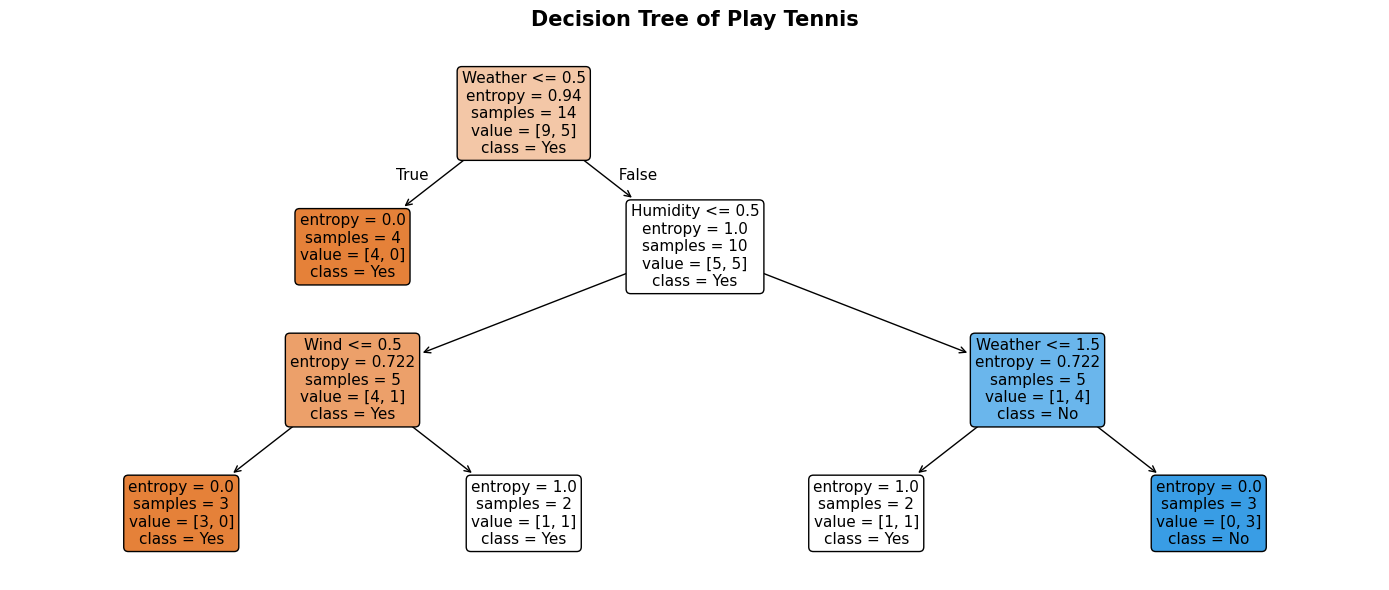

In [115]:
plt.figure(figsize=(14, 6))
plot_tree(de,feature_names=["Weather","Humidity","Wind"],class_names = ["Yes","No"] , filled = True,rounded = True,fontsize = 11)
plt.title("Decision Tree of Play Tennis", fontsize=15, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

## Finally!!!!!!!! My Decision Tree Model is Completed.